## 주요 변경점 및 결과
1. 제대로 된 Knowledge Distillation 위해 Teacher Model 먼저 학습 -> 결과 보기
2. Knowledge_Distillation v1에서 Student Model & Parameter Sweep
3. Knowledge_Distillation v2처럼 중간 레이어 특징을 배우도록 하는 방식의 추가 -> 마지막에 Flatten 하는 부분을 추출
4. Ablation Study에서 Video AUG 결과 보고 추가할지 뺄지 결정

In [1]:
import os
os.environ['CUDA_MPS_PIPE_DIRECTORY'] = '/tmp/nvidia-mps'
os.environ['CUDA_MPS_LOG_DIRECTORY'] = '/tmp/nvidia-mps-log'

## 1. 라이브러리 및 환경 설정

In [2]:
import os
import sys
import json
import random
import pandas as pd
import numpy as np
import cv2
import shutil
import timm
import wandb
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from pathlib import Path

ROOT = Path.cwd().resolve().parent
SRC_DIR = (Path.cwd() / '../src').resolve()
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from augmentations import build_default_transforms
from output_paths import allocate_output_paths
from reproducibility import make_generator, seed_everything, seed_worker

# /src 에서 실행하는 기준 경로 설정
DATA_DIR = (Path.cwd() / '../data').resolve()
TEACHER_EXPERIMENT_NAME = "Data_AUG_Test"
TEACHER_EXPERIMENT_VERSION = "v3.2"
TEACHER_WEIGHT_DIR = ROOT / "outputs" / "weights" / TEACHER_EXPERIMENT_NAME / TEACHER_EXPERIMENT_VERSION

EXPERIMENT_NAME = "Knowledge Distillation"
EXPERIMENT_VERSION = "v3"
WEIGHT_DIR = ROOT / "outputs" / "weights" / EXPERIMENT_NAME / EXPERIMENT_VERSION
SUBMISSION_DIR = ROOT / "outputs" / "submissions" / EXPERIMENT_NAME / EXPERIMENT_VERSION
EDA_DIR = ROOT / "outputs" / "eda_preprocessing" / EXPERIMENT_NAME / EXPERIMENT_VERSION

WEIGHT_DIR.mkdir(parents=True, exist_ok=True)
SUBMISSION_DIR.mkdir(parents=True, exist_ok=True)
EDA_DIR.mkdir(parents=True, exist_ok=True)

assert DATA_DIR.exists(), f"data 폴더를 찾지 못했습니다: {DATA_DIR}"
print(f"DATA_DIR: {DATA_DIR}")

# 하이퍼파라미터 설정
CFG = {
    # Basic
    'IMG_SIZE': 320,
    'EPOCHS': [30],
    'LEARNING_RATE': 3e-4,
    'MIN_LR': 1e-6,
    'BATCH_SIZE': 16,
    'SEED': 42,
    'NUM_WORKERS': 16,
    'USE_AMP' : True,
    # Regularization & Stability
    'WEIGHT_DECAY': 1e-4,  # L2 regularization
    'TEMPERATURE' : 2.0,
    'EMA_DECAY': 0.999, # 시계열에서 window size만큼 고려해 지역적 평균 구하는 방식으로 노이즈를 제거
    'EMA_USE_FOR_EVAL': True,
    'PATIENCE' : 10,
    # Augmentation & TTA
    'TTA_CANDIDATES': [ # TEST TIME AUGMENTATION
        ['none'],
        ['none', 'hflip'],
        ['none', 'hflip', 'crop95'],
    ],
    'BASIC_LOSS_WEIGHT': 0.5,
    'LOGIT_LOSS_WEIGHT': 0.5,
    'FEATURE_LOSS_WEIGHT': 0.1,
    # video frame augmentation (for unstable videos)
    'VIDEO_AUG_ENABLE': True,
    'VIDEO_AUG_CACHE': True,
    'UNSTABLE_START_MIN_SEC': 0.5,
    'UNSTABLE_START_MAX_SEC': 1.0,
    'UNSTABLE_FRAMES_MIN': 2,
    'UNSTABLE_FRAMES_MAX': 3,
    'STABLE_END_MIN_SEC': 9.0,
    'STABLE_END_MAX_SEC': 10.0,
    'STABLE_FRAMES_PER_VIDEO': 2,
}

TEACHER_BACKBONE_CANDIDATES = [
    "efficientnetv2_rw_m",
]

STUDENT_BACKBONE_CANDIDATES = [
    "efficientnetv2_rw_s",
]

teacher_selected_backbones = []
for name in TEACHER_BACKBONE_CANDIDATES:
    try:
        timm.create_model(name, pretrained=False, num_classes=0, global_pool="")
        teacher_selected_backbones.append(name)
    except Exception as exc:
        print(f"skip backbone: {name}, reason: {exc}")

student_selected_backbones = []
for name in STUDENT_BACKBONE_CANDIDATES:
    try:
        timm.create_model(name, pretrained=False, num_classes=0, global_pool="")
        student_selected_backbones.append(name)
    except Exception as exc:
        print(f"skip backbone: {name}, reason: {exc}")

teacher_model_candidates = TEACHER_BACKBONE_CANDIDATES
BEST_TEACHER_BACKBONE = teacher_model_candidates[0]

print("teacher_selected_backbones:", teacher_selected_backbones)
print("student_selected_backbones:", student_selected_backbones)
assert teacher_selected_backbones, "No teacher candidate backbones are available in this timm installation."
assert student_selected_backbones, "No student candidate backbones are available in this timm installation."

seed_everything(CFG['SEED'])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

DATA_DIR: /home/vsc/LLM_TUNE/structure-stability/data
teacher_selected_backbones: ['efficientnetv2_rw_m']
student_selected_backbones: ['efficientnetv2_rw_s']
cuda


## 2. 데이터 로드 및 학습/검증 데이터 분할

In [3]:
# 1. 데이터 로드
train_df = pd.read_csv(DATA_DIR / 'train.csv', encoding='utf-8-sig')
val_df = pd.read_csv(DATA_DIR / 'dev.csv', encoding='utf-8-sig')

print(f"학습 데이터 개수: {len(train_df)}")
print(f"검증 데이터 개수: {len(val_df)}")

학습 데이터 개수: 1000
검증 데이터 개수: 100


## 3-1. CheckerboardTopNormalizer 클래스 & CheckerboardTopNormConfig 설정 정의

In [4]:
from __future__ import annotations
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Optional
from PIL import Image

import cv2
import numpy as np
import matplotlib.pyplot as plt

@dataclass(frozen=True)
class CheckerboardTopNormConfig:
    enabled: bool = True
    ring_ratio: float = 0.10
    rot_line_min: int = 10
    rot_conf_min: float = 0.20
    pad_value: int = 128


def _estimate_mask(rgb: np.ndarray) -> np.ndarray:
    """
    지저분한 마스크 다듬기 & 원하는 물체만 골라내기
    """
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY) 
    hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV) 
    sat = hsv[:, :, 1]
    val = hsv[:, :, 2]

    s_thr = float(np.percentile(sat, 60.0))
    g_thr = float(np.percentile(gray, 45.0))
    v_thr = float(np.percentile(val, 35.0))

    mask = ((sat > s_thr) | (gray < g_thr) | (val < v_thr)).astype(np.uint8) * 255
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8), iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((5, 5), np.uint8), iterations=2)

    n, labels, stats, _ = cv2.connectedComponentsWithStats(mask, 8)
    if n <= 1:
        return (mask > 0).astype(np.uint8)

    best = 1
    best_area = 0
    h, w = gray.shape
    for i in range(1, n):
        x, y, ww, hh, area = stats[i].tolist()
        if area > best_area and ww > 8 and hh > 8 and area < 0.995 * h * w:
            best = i
            best_area = area
    return (labels == best).astype(np.uint8)


def _ring_mask(h: int, w: int, ratio: float) -> np.ndarray:
    r = max(1, int(round(min(h, w) * ratio)))
    mask = np.zeros((h, w), dtype=np.uint8)
    mask[:r, :] = 1
    mask[-r:, :] = 1
    mask[:, :r] = 1
    mask[:, -r:] = 1
    return mask


def _line_angles(edge: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """
    추출한 Edge 이미지에서 직선을 찾고, 기울어진 각을 계산해 반환하는 함수
    """
    lines = cv2.HoughLinesP(edge, 1, np.pi / 180.0, threshold=30, minLineLength=24, maxLineGap=6)
    if lines is None or len(lines) == 0:
        return np.zeros((0,), dtype=np.float32), np.zeros((0,), dtype=np.float32)

    angs = []
    lens = []
    for line in lines[:400]:
        x1, y1, x2, y2 = line[0].tolist()
        dx = float(x2 - x1)
        dy = float(y2 - y1)
        ln = float(np.hypot(dx, dy))
        if ln < 8:
            continue
        ang = (float(np.degrees(np.arctan2(dy, dx))) + 180.0) % 180.0
        angs.append(ang)
        lens.append(ln)
    if len(angs) == 0:
        return np.zeros((0,), dtype=np.float32), np.zeros((0,), dtype=np.float32)
    return np.asarray(angs, dtype=np.float32), np.asarray(lens, dtype=np.float32)


def estimate_top_rotation(rgb: np.ndarray, cfg: CheckerboardTopNormConfig) -> dict[str, float | bool | int | str]:
    h, w = rgb.shape[:2]
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    fg = _estimate_mask(rgb) # 원하는 물체를 추출하는 함수
    bg = (1 - fg).astype(np.uint8)
    if int(bg.sum()) < int(0.03 * h * w):
        bg = _ring_mask(h, w, cfg.ring_ratio)

    gx = cv2.Scharr(gray, cv2.CV_32F, 1, 0)
    gy = cv2.Scharr(gray, cv2.CV_32F, 0, 1)
    mag = cv2.magnitude(gx, gy)
    mag = (mag / (mag.max() + 1e-6) * 255.0).astype(np.uint8)
    edges = cv2.Canny(mag, 40, 120)
    edges = cv2.bitwise_and(edges, edges, mask=(bg * 255))

    angles, lengths = _line_angles(edges)
    line_n = int(len(angles))
    if line_n == 0:
        return {
            "angle_deg": 0.0,
            "rot_conf": 0.0,
            "rot_ok": False,
            "rot_fail_reason": "no_lines",
            "rot_line_count": 0,
        }

    hist, _ = np.histogram(angles, bins=180, range=(0.0, 180.0), weights=lengths)
    peak_primary = int(np.argmax(hist))
    peak_primary_value = float(hist[peak_primary])

    hist_secondary = hist.copy()
    for d in range(-8, 9):
        hist_secondary[(peak_primary + d) % 180] = 0.0
    peak_secondary = int(np.argmax(hist_secondary))
    peak_secondary_value = float(hist_secondary[peak_secondary])
    peak_orthogonal = float(hist[(peak_primary + 90) % 180])

    mods = np.mod(angles, 90.0)
    theta = mods * (2.0 * np.pi / 90.0)
    cx = float(np.sum(lengths * np.cos(theta)))
    cy = float(np.sum(lengths * np.sin(theta)))
    rot_mod90 = float((np.degrees(np.arctan2(cy, cx)) * (90.0 / 360.0)) % 90.0)

    peak_ratio_score = peak_primary_value / (peak_primary_value + peak_secondary_value + 1e-6)
    line_score = min(1.0, line_n / 60.0)
    spread = float(np.sqrt(np.average((mods - np.average(mods, weights=lengths)) ** 2, weights=lengths)))
    spread_score = float(np.clip(1.0 - spread / 20.0, 0.0, 1.0))
    ortho_score = float(np.clip(peak_orthogonal / (peak_primary_value + 1e-6), 0.0, 1.0))
    conf = float(np.clip(0.35 * peak_ratio_score + 0.25 * line_score + 0.20 * spread_score + 0.20 * ortho_score, 0.0, 1.0))

    reasons = []
    if line_n < cfg.rot_line_min:
        reasons.append("line_count_low")
    if conf < cfg.rot_conf_min:
        reasons.append("confidence_low")

    return {
        "angle_deg": -rot_mod90,
        "rot_conf": conf,
        "rot_ok": len(reasons) == 0,
        "rot_fail_reason": "|".join(reasons),
        "rot_line_count": line_n,
    }

def rotate_rgb(rgb: np.ndarray, angle_deg: float, pad_value: int) -> np.ndarray:
    if abs(angle_deg) < 1e-6:
        return rgb
    h, w = rgb.shape[:2]
    matrix = cv2.getRotationMatrix2D((w / 2.0, h / 2.0), angle_deg, 1.0)
    return cv2.warpAffine(
        rgb,
        matrix,
        (w, h),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=(pad_value, pad_value, pad_value),
    )


class CheckerboardTopNormalizer:
    def __init__(self, cfg: Optional[CheckerboardTopNormConfig] = None) -> None:
        self.cfg = cfg or CheckerboardTopNormConfig()
        self._angle_cache: Dict[str, Optional[float]] = {}

    def normalize(self, path: str | Path, image: Image.Image, debug_save_path: Optional[Path] = None) -> Image.Image:
            """
            이미지를 정규화(회전 보정)합니다.
            debug_save_path가 전달되면 중간 분석 과정을 시각화하여 저장합니다.
            """
            if not self.cfg.enabled:
                return image

            key = str(Path(path).expanduser().resolve())
            
            # 1. 각도 계산 및 캐싱 (이미 계산된 적이 없다면 실행)
            if key not in self._angle_cache:
                rgb = np.asarray(image.convert("RGB"))
                info = estimate_top_rotation(rgb, self.cfg)
                
                # 성공 여부에 따라 각도 저장 (실패 시 None)
                self._angle_cache[key] = float(info["angle_deg"]) if bool(info["rot_ok"]) else None

                # [핵심 수정] 파라미터로 받은 debug_save_path가 있을 때만 시각화 함수 호출
                if debug_save_path:
                    self._save_debug_plot(rgb, info, debug_save_path)

            # 2. 캐시된 각도 가져오기
            angle = self._angle_cache[key]
            
            # 보정할 각도가 없거나(None), 실패한 경우 원본 반환
            if angle is None:
                return image

            # 3. 실제 회전 적용
            rgb = np.asarray(image.convert("RGB"))
            rotated = rotate_rgb(rgb, angle_deg=angle, pad_value=self.cfg.pad_value)
            
            return Image.fromarray(rotated)
    
    def _save_debug_plot(self, rgb: np.ndarray, info: dict, save_path: Path):
        # 중간 과정 재현 (시각화용)
        fg_mask = _estimate_mask(rgb)
        bg_mask = (1 - fg_mask).astype(np.uint8)
        if int(bg_mask.sum()) < int(0.03 * rgb.shape[0] * rgb.shape[1]):
            bg_mask = _ring_mask(rgb.shape[0], rgb.shape[1], self.cfg.ring_ratio)
        
        gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
        edges = cv2.Canny(gray, 40, 120) # 단순화를 위해 바로 Canny 적용 가능
        masked_edges = cv2.bitwise_and(edges, edges, mask=(bg_mask * 255))
        
        line_img = rgb.copy()
        lines = cv2.HoughLinesP(masked_edges, 1, np.pi / 180.0, threshold=30, minLineLength=24, maxLineGap=6)
        if lines is not None:
            for line in lines[:100]:
                x1, y1, x2, y2 = line[0]
                cv2.line(line_img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        
        rotated = rotate_rgb(rgb, info["angle_deg"], self.cfg.pad_value)

        # 플롯 생성
        fig, axes = plt.subplots(1, 4, figsize=(20, 5))
        titles = ["Original", "Edges", "Lines", "Result"]
        imgs = [rgb, masked_edges, line_img, rotated]
        
        for ax, img, title in zip(axes, imgs, titles):
            ax.imshow(img, cmap='gray' if len(img.shape) == 2 else None)
            ax.set_title(title)
            ax.axis('off')
        
        fig.suptitle(f"Angle: {info['angle_deg']:.2f}° | Conf: {info['rot_conf']:.2f}", fontsize=15)
        
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, bbox_inches='tight')
        plt.close(fig)

## 3-2. CheckerboardTopNormalization 을 포함한 커스텀 클래스 + 데이터 로더 위한 함수 정의

In [5]:
class MultiViewDataset(Dataset):
    def __init__(
        self,
        df,
        root_dir,
        transform=None, # 이 transform이 Compose라면 내부 시점별 분기가 필요할 수 있음
        is_test=False,
        checkerboard_top_normalize: bool = True
    ):
        self.df = df.reset_index(drop=True)
        self.root_dir = root_dir
        self.transform = transform
        self.is_test = is_test
        self.label_map = {'stable': 0, 'unstable': 1}
        
        # 체커보드 정규화기 설정
        self.top_normalizer = CheckerboardTopNormalizer(
            CheckerboardTopNormConfig(enabled=True)
        ) if checkerboard_top_normalize else None

    def __len__(self):
        return len(self.df)

    def _load_img(self, sid: str, view: str, sample_dir: str) -> Image.Image:
        # 비디오 증강 데이터 여부 확인 (ID prefix 사용)
        is_augv = sid.startswith('AUGV_')
        
        # 경로 설정
        path = Path(sample_dir) / sid / f"{view}.png"
        image = Image.open(path).convert("RGB")
        
        # [핵심 수정] Top View 정규화 로직
        # 비디오 증강 데이터(AUGV_)가 아닐 때만 체커보드 정규화 수행
        if view == "top" and self.top_normalizer is not None and not is_augv:
            debug_path = None
            # 학습/검증 중 앞부분만 디버깅 이미지 저장
            if not self.is_test and len(self.top_normalizer._angle_cache) < 20:
                folder = "train" if "TRAIN" in sid else "dev"
                debug_path = Path(f"./debug_plots/{folder}/{sid}_top.png")

            image = self.top_normalizer.normalize(path, image, debug_save_path=debug_path)
            
        return image

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        sid = str(row['id'])
        # sample_dir이 row에 있으면 사용, 없으면 기본 root_dir 사용
        sample_dir = row['sample_dir'] if 'sample_dir' in row else self.root_dir

        views = []
        for name in ['front', 'top']:
            # 정규화 로직이 포함된 이미지 로드 호출
            image = self._load_img(sid, name, sample_dir)
            
            # transform 적용
            if self.transform:
                # 만약 transform이 시점별로 다르다면(Compose 내부 분기 등) 여기서 처리
                image = self.transform(image)
            
            views.append(image)

        if self.is_test:
            return views

        label = self.label_map[row['label']]
        return views, label

In [6]:
def _extract_frame_by_sec(cap, sec, fps, frame_count):
    # 매 프레임에 해당하는 장면을 가져오는 함수
    frame_idx = int(max(0, min(frame_count - 1, round(sec * fps))))
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ok, frame = cap.read()
    if not ok:
        return None
    return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)


def _extract_last_frame(cap, frame_count):
    # 가장 마지막 프레임을 가져오는 함수
    last_idx = max(0, frame_count - 1)
    cap.set(cv2.CAP_PROP_POS_FRAMES, last_idx)
    ok, frame = cap.read()
    if not ok:
        return None
    return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)


def _video_aug_cache_signature(cfg):
    # VIDEO_AUG에 해당하는 CFG만 가져오는 함수
    keys = [
        'SEED',
        'UNSTABLE_START_MIN_SEC',
        'UNSTABLE_START_MAX_SEC',
        'UNSTABLE_FRAMES_MIN',
        'UNSTABLE_FRAMES_MAX',
        'STABLE_END_MIN_SEC',
        'STABLE_END_MAX_SEC',
        'STABLE_FRAMES_PER_VIDEO',
    ]
    return {k: cfg.get(k) for k in keys}

def detect_collapse_start(cap, fps, frame_count, motion_threshold=0.02):
    """
    프레임 간 픽셀 변화량으로 붕괴 시작 시점 탐지
    """
    prev_frame = None
    collapse_sec = None

    # 전체 영상을 일정 간격으로 샘플링
    sample_interval = max(1, int(fps * 0.2))  # 0.2초 간격

    for frame_idx in range(0, frame_count, sample_interval):
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ok, frame = cap.read()
        if not ok:
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY).astype(float) / 255.0

        if prev_frame is not None:
            # 프레임 간 변화량 계산
            diff = np.mean(np.abs(gray - prev_frame))
            if diff > motion_threshold:
                collapse_sec = frame_idx / fps
                break  # 첫 번째 큰 변화 시점

        prev_frame = gray

    return collapse_sec  # None이면 붕괴 미감지

def build_video_augmented_df(train_df, data_dir, cfg):
    """
    train의 simulation.mp4에서 프레임 추출 (train의 경우 )
    stable : 그냥 계속 동일한 프레임들이 나올테니, 그냥 마지막 프레임 뽑음
    unstable : 0~10초 내에 구조물이 무너지는 순간이 있을텐데, 이 변화량이 큰 순간을 포착
    """
    train_root = data_dir / 'train'
    aug_root = data_dir / 'train_video_aug'
    aug_root.mkdir(parents=True, exist_ok=True)

    cache_csv = aug_root / 'aug_df.csv'
    cache_meta = aug_root / 'cache_meta.json'
    cache_sig = _video_aug_cache_signature(cfg)

    if cfg.get('VIDEO_AUG_CACHE', True) and cache_csv.exists() and cache_meta.exists():
        try:
            meta = json.loads(cache_meta.read_text())
            if meta.get('signature') == cache_sig:
                cached_df = pd.read_csv(cache_csv)
                if not cached_df.empty:
                    cached_df['sample_dir'] = str(aug_root)
                    print(f'video aug cache hit: {len(cached_df)} samples from {cache_csv}')
                    return cached_df
        except Exception as e:
            print(f'video aug cache read failed. rebuild cache. ({e})')

    # 캐시 미스 시 기존 AUGV_* 폴더만 정리 후 재생성
    for p in aug_root.glob('AUGV_*'):
        if p.is_dir():
            shutil.rmtree(p, ignore_errors=True)

    rng = np.random.default_rng(cfg['SEED'])
    stable_rows = []
    unstable_rows = []
    saved_idx = 0

    def save_aug(img, label):
        nonlocal saved_idx
        aug_id = f'AUGV_{saved_idx:07d}'
        out_dir = aug_root / aug_id
        out_dir.mkdir(parents=True, exist_ok=True)
        Image.fromarray(img).save(out_dir / 'front.png')
        Image.fromarray(img).save(out_dir / 'top.png')
        row = {'id': aug_id, 'label': label, 'sample_dir': str(aug_root)}
        saved_idx += 1
        return row

    # 1) stable 증강: 영상의 마지막 프레임 1장씩 사용
    all_ids = train_df['id'].tolist()
    for sample_id in tqdm(all_ids, desc='Video aug stable(last-frame)', dynamic_ncols=True, ascii=True):
        video_path = train_root / sample_id / 'simulation.mp4'
        if not video_path.exists():
            continue

        cap = cv2.VideoCapture(str(video_path))
        if not cap.isOpened():
            cap.release()
            continue

        frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if frame_count <= 0:
            cap.release()
            continue

        img = _extract_last_frame(cap, frame_count)
        cap.release()
        if img is None:
            continue

        stable_rows.append(save_aug(img, 'stable'))

    # 2) unstable 증강: 실제로 해당 구조물이 붕괴하기 시작하는 시점을 탐지
    unstable_ids = train_df.loc[train_df['label'] == 'unstable', 'id'].tolist()
    for sample_id in tqdm(unstable_ids, desc='Video aug unstable(collapse-detect)', dynamic_ncols=True, ascii=True):
        cap = cv2.VideoCapture(str(video_path))
        fps = cap.get(cv2.CAP_PROP_FPS)
        frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        # ← 핵심 변경: 실제 붕괴 시작 시점 탐지
        collapse_sec = detect_collapse_start(cap, fps, frame_count)

        if collapse_sec is None:
            # 탐지 실패 시 기존 방식 fallback
            low  = cfg['UNSTABLE_START_MIN_SEC']
            high = cfg['UNSTABLE_START_MAX_SEC']
        else:
            # 탐지 성공 시 붕괴 시점 기준으로 샘플링 구간 설정
            low  = max(0.0, collapse_sec - 0.3)   # 붕괴 0.3초 전
            high = min(collapse_sec + 0.5,          # 붕괴 0.5초 후
                       frame_count / fps)

        n_unstable = int(rng.integers(
            cfg['UNSTABLE_FRAMES_MIN'],
            cfg['UNSTABLE_FRAMES_MAX'] + 1
        ))
        unstable_secs = rng.uniform(low, high, size=n_unstable)

        for sec in unstable_secs:
            img = _extract_frame_by_sec(cap, sec, fps, frame_count)
            if img is None:
                continue
            unstable_rows.append(save_aug(img, 'unstable'))

        cap.release()

    stable_df = pd.DataFrame(stable_rows)
    unstable_df = pd.DataFrame(unstable_rows)

    if stable_df.empty or unstable_df.empty:
        print('video aug warning: stable/unstable 중 하나가 비어 비율 매칭 불가')
        return pd.DataFrame(columns=['id', 'label', 'sample_dir'])

    # 3) stable 개수에 맞춰 unstable 개수 정렬
    target_unstable = len(stable_df)
    if len(unstable_df) >= target_unstable:
        unstable_bal = unstable_df.sample(n=target_unstable, random_state=cfg['SEED'])
    else:
        unstable_bal = unstable_df.sample(n=target_unstable, replace=True, random_state=cfg['SEED'])

    aug_df = pd.concat([stable_df, unstable_bal], ignore_index=True)
    aug_df = aug_df.sample(frac=1.0, random_state=cfg['SEED']).reset_index(drop=True)

    # 캐시 저장
    if cfg.get('VIDEO_AUG_CACHE', True):
        aug_df.to_csv(cache_csv, index=False)
        cache_meta.write_text(json.dumps({'signature': cache_sig}, ensure_ascii=False, indent=2))
        print(f'video aug cache saved: {cache_csv}')

    print(f'video aug stable(last-frame): {len(stable_df)}')
    print(f'video aug unstable(sampled): {len(unstable_bal)}')
    return aug_df

In [7]:
train_transform, test_transform = build_default_transforms(CFG['IMG_SIZE'])

# 원본 학습 데이터(기본 1:1)
train_df_copy = train_df.copy()
train_df_copy['sample_dir'] = str(DATA_DIR / 'train')

# 비디오 프레임 기반 증강 데이터 생성
if CFG.get('VIDEO_AUG_ENABLE', False):
    aug_df = build_video_augmented_df(train_df, DATA_DIR, CFG)
    if len(aug_df) > 0:
        train_df_copy = pd.concat([train_df_copy, aug_df], ignore_index=True)
        print(f'video aug added: {len(aug_df)} samples')
    else:
        print('video aug added: 0 samples (check video availability)')

# 최종 학습 비율 확인
print('Final train class ratio:')
print(train_df_copy['label'].value_counts())

video aug cache hit: 2000 samples from /home/vsc/LLM_TUNE/structure-stability/data/train_video_aug/aug_df.csv
video aug added: 2000 samples
Final train class ratio:
label
unstable    1500
stable      1500
Name: count, dtype: int64


In [8]:
val_df_for_eval = val_df.copy()
val_df_for_eval['sample_dir'] = str(DATA_DIR / 'dev')

# 1. 학습/검증 세트 준비
train_dataset = MultiViewDataset(train_df_copy, str(DATA_DIR / 'train'), train_transform, is_test=False)
val_dataset = MultiViewDataset(val_df_for_eval, str(DATA_DIR / 'dev'), test_transform, is_test=False)

train_loader = DataLoader(
    train_dataset,
    batch_size=CFG['BATCH_SIZE'],
    shuffle=True,
    num_workers=CFG['NUM_WORKERS'],
    pin_memory=(device.type == 'cuda'), # CPU RAM -> GPU VRAM 전송 시 더 빠른 전송 경로 사용
    worker_init_fn=seed_worker,
    generator=make_generator(CFG['SEED'])
)
val_loader = DataLoader(
    val_dataset,
    batch_size=CFG['BATCH_SIZE'],
    shuffle=False,
    num_workers=CFG['NUM_WORKERS'],
    pin_memory=(device.type == 'cuda'), # CPU RAM -> GPU VRAM 전송 시 더 빠른 전송 경로 사용
    worker_init_fn=seed_worker,
    generator=make_generator(CFG['SEED'] + 1)
)

# 2. 테스트 세트 준비
test_df = pd.read_csv(DATA_DIR / 'sample_submission.csv', encoding='utf-8-sig')
test_df_for_infer = test_df.copy()
test_df_for_infer['sample_dir'] = str(DATA_DIR / 'test')

test_dataset = MultiViewDataset(test_df_for_infer, str(DATA_DIR / 'test'), test_transform, is_test=True)
test_loader = DataLoader(
    test_dataset,
    batch_size=CFG['BATCH_SIZE'],
    shuffle=False,
    num_workers=CFG['NUM_WORKERS'],
    pin_memory=(device.type == 'cuda'),
    worker_init_fn=seed_worker,
    generator=make_generator(CFG['SEED'] + 2)
)

## 4-1. 모델 정의 (Multi-View )

In [9]:
from models import (
    EMAConfig,
    ModelEMA
)
import dataclasses

EMA_CONFIG = EMAConfig(decay=CFG['EMA_DECAY'])
artifacts = allocate_output_paths(experiment_name='knowledge_distillation', major_version='v3.0')

In [10]:
from transformers import AutoModel
import os

DEPTH_ANYTHING_MODEL_DIR = "/home/vsc/LLM/model/Depth-Anything-V2-Small"

@dataclass(frozen=True)
class FlexibleMultiViewFeatureFusionConfig:
    backbone_name: str = "efficientnetv2_rw_s"
    pretrained: bool = True
    hidden_dim: int = 512
    mid_dim: int = 128
    dropout: float = 0.3
    out_dim: int = 1
    img_size: int = 320

class FlexibleMultiViewFeatureFusion(nn.Module):
    def __init__(self, config: FlexibleMultiViewFeatureFusionConfig):
        super().__init__()
        self.config = config
        
        # 1. 백본 로드 (timm vs Hugging Face 분기)
        if "depth_anything_small" in config.backbone_name:
            # DepthAnything 모델 로드 (Hugging Face)
            if not os.path.exists(DEPTH_ANYTHING_MODEL_DIR):
                raise FileNotFoundError(f"로컬 모델 경로를 찾을 수 없습니다: {DEPTH_ANYTHING_MODEL_DIR}")
                
            self.backbone = AutoModel.from_pretrained(DEPTH_ANYTHING_MODEL_DIR)
            self.feat_dim = 384 # depth-anything-small(DINOv2 small)의 Feature 차원
        else:
            model_kwargs = {
                "model_name": config.backbone_name,
                "pretrained": config.pretrained,
                "num_classes": 0,
                "global_pool": ""
            }
            if any(k in config.backbone_name.lower() for k in ["swin", "vit"]):
                model_kwargs["img_size"] = config.img_size

            self.backbone = timm.create_model(**model_kwargs)
            self.feat_dim = self.backbone.num_features

        self.fusion = nn.Sequential(
            nn.Linear(self.feat_dim * 4, config.hidden_dim),
            nn.BatchNorm1d(config.hidden_dim), # 백본마다 값의 스케일이 다르므로 BN 추가 강력 권장
            nn.ReLU(),
            nn.Dropout(config.dropout),
            nn.Linear(config.hidden_dim, config.mid_dim),
            nn.ReLU()
        )
        
        self.head = nn.Linear(config.mid_dim, config.out_dim)

    def _extract_and_pool(self, x: torch.Tensor) -> torch.Tensor:
        """
        입력된 텐서의 형태(CNN, Swin, ViT)를 동적으로 파악하여
        (Batch, Feature_Dim) 크기의 1D 벡터로 Global Average Pooling을 수행합니다.
        """
        feat = self.backbone.forward_features(x)

        # 1. 4D Tensor (CNN 또는 Swin)
        if feat.ndim == 4:
            # (B, C, H, W) 형태인 경우 (EfficientNet, ConvNeXt 등)
            if feat.shape[1] == self.feat_dim:
                return feat.mean(dim=(2, 3))
            
            # (B, H, W, C) 형태인 경우 (특정 버전의 Swin 등)
            elif feat.shape[-1] == self.feat_dim:
                return feat.mean(dim=(1, 2))

        # 2. 3D Tensor (ViT 등 Sequence 형태: (B, Sequence_Length, C))
        elif feat.ndim == 3:
            if feat.shape[-1] == self.feat_dim:
                return feat.mean(dim=1) # 모든 토큰의 평균을 냄 (GAP)

        raise ValueError(f"Unsupported feature shape: {tuple(feat.shape)} for backbone={self.config.backbone_name}")

    def forward(self, views, return_feat=False):
        # 2. 백본을 거쳐 무조건 (B, feat_dim) 형태로 맞춰진 특징 벡터 획득
        f1 = self._extract_and_pool(views[0])
        f2 = self._extract_and_pool(views[1])

        combined = torch.cat([f1, f2, torch.abs(f1 - f2), f1 * f2], dim=1)
        
        # 3. 차원에 구애받지 않고 안전하게 Concat 진행
        fused = self.fusion(combined)  # (B, mid_dim)
        out   = self.head(fused)                         # (B, 1)

        if return_feat:
            return out, fused

        return out

## 5. 학습 및 검증 루프 구현

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.cuda.amp import autocast, GradScaler

import torch
import torch.nn.functional as F
from torch.cuda.amp import autocast
from tqdm import tqdm

def train_one_epoch(
    teacher_model, 
    student_model, 
    loader, 
    criterion, 
    optimizer, 
    device, 
    ema=None, 
    temperature=3.0, 
    basic_loss_weight=1,
    logit_loss_weight=0.1,    
    feature_loss_weight=0.1,  
    scaler=None, 
    epoch=0
):
    student_model.train()
    teacher_model.eval() 
    
    # 에포크 전체 Loss를 누적할 변수 세분화
    epoch_total_loss = 0
    epoch_task_loss = 0
    epoch_logit_kd_loss = 0
    epoch_feat_kd_loss = 0
    
    pbar = tqdm(enumerate(loader), total=len(loader), desc=f"Epoch {epoch}", dynamic_ncols=True, ascii=True)
    
    for i, (views, labels) in pbar:
        views  = [v.to(device) for v in views]
        labels = labels.to(device).float()
        
        optimizer.zero_grad()

        with autocast():
            # ==========================================================
            # 1. Teacher Inference (Logit & Feature 동시 추출)
            # ==========================================================
            with torch.no_grad():
                teacher_logits, teacher_feats = teacher_model(views, return_feat=True)
                teacher_logits = teacher_logits.view(-1)

            # ==========================================================
            # 2. Student Inference (Task Loss)
            # ==========================================================
            outputs, student_feats = student_model(views, return_feat=True)
            outputs = outputs.view(-1)
            loss_task = criterion(outputs, labels)

            # ==========================================================
            # 3. Logit Distillation Loss 계산 (출력 증류)
            # ==========================================================
            teacher_probs = torch.sigmoid(teacher_logits / temperature)
            loss_distill_raw = F.binary_cross_entropy_with_logits(
                outputs / temperature, 
                teacher_probs
            )
            loss_distill_raw = loss_distill_raw * (temperature ** 2)

            # ==========================================================
            # 4. Feature Distillation Loss 계산 (특징 증류)
            # ==========================================================    
            batch_size = student_feats.size(0)
            target = torch.ones(batch_size).to(device)
            
            loss_feat_kd_raw = F.cosine_embedding_loss(
                student_feats, 
                teacher_feats.detach(), 
                target
            )     

            # ==========================================================
            # 5. 최종 Loss 결합 (Orthogonal Sum)
            # ==========================================================
            loss_logit_kd = logit_loss_weight * loss_distill_raw
            loss_feat_kd  = feature_loss_weight * loss_feat_kd_raw
                    
            loss = basic_loss_weight * loss_task + loss_logit_kd + loss_feat_kd

        # ==========================================================
        # 6. 역전파 및 최적화
        # ==========================================================
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        if ema is not None:
            ema.update(student_model)

        # 값 누적 (변수명 일치)
        epoch_total_loss += loss.item()
        epoch_task_loss += loss_task.item()
        epoch_logit_kd_loss += loss_logit_kd.item()
        epoch_feat_kd_loss += loss_feat_kd.item()

    # ==========================================================
    # 7. 에포크 종료 후 평균값 계산 및 로깅
    # ==========================================================
    num_batches = len(loader)
    avg_total = epoch_total_loss / num_batches
    avg_task = epoch_task_loss / num_batches
    avg_logit_kd = epoch_logit_kd_loss / num_batches
    avg_feat_kd = epoch_feat_kd_loss / num_batches

    # [최종 출력] 에포크 결과 요약 (상세 지표 모두 출력)
    print(f"\n>> [Epoch {epoch}] Total: {avg_total:.5f} | Task: {avg_task:.5f} | LogitKD: {avg_logit_kd:.5f} | FeatKD: {avg_feat_kd:.5f} | LR: {optimizer.param_groups[0]['lr']:.8f}")

    # WandB 기록
    wandb.log({
        'train/epoch_total_loss': avg_total,
        'train/epoch_task_loss': avg_task,
        'train/epoch_logit_kd_loss': avg_logit_kd,
        'train/epoch_feat_kd_loss': avg_feat_kd,
        'epoch': epoch
    })

    return avg_total

def validate(model, loader, criterion, device):
    model.eval()
    val_loss  = 0
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Validation", dynamic_ncols=True, ascii=True):
            views, labels = batch[0], batch[1]
            views  = [v.to(device) for v in views]
            labels = labels.to(device).float()

            outputs = model(views).view(-1)
            loss    = criterion(outputs, labels)
            val_loss += loss.item()

            all_preds.append(torch.sigmoid(outputs).cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_probs  = np.concatenate(all_preds,  axis=0).astype(np.float64)
    all_labels = np.concatenate(all_labels, axis=0).astype(np.float64)

    eps = 1e-15
    p = np.clip(all_probs, eps, 1 - eps)
    logloss_score = -np.mean(all_labels * np.log(p) + (1 - all_labels) * np.log(1 - p))
    acc_score     = np.mean((all_probs > 0.5) == all_labels)

    return logloss_score, acc_score

# -------------------------
# TTA helpers
# -------------------------
def _center_crop_and_resize(x, crop_ratio=0.95):
    # x: [B, C, H, W]
    b, c, h, w = x.shape
    ch, cw = int(h * crop_ratio), int(w * crop_ratio)
    y1 = (h - ch) // 2
    x1 = (w - cw) // 2
    cropped = x[:, :, y1:y1 + ch, x1:x1 + cw]
    return F.interpolate(cropped, size=(h, w), mode='bilinear', align_corners=False)


def apply_tta_to_views(views, tta_name):
    if tta_name == 'none':
        return views
    if tta_name == 'hflip':
        return [torch.flip(v, dims=[3]) for v in views]
    if tta_name == 'crop95':
        return [_center_crop_and_resize(v, crop_ratio=0.95) for v in views]
    raise ValueError(f'Unknown TTA: {tta_name}')


def predict_probs_with_tta(model, loader, device, tta_names=None, has_labels=False, desc='Inference TTA'):
    if tta_names is None:
        tta_names = ['none']

    model.eval()
    all_probs  = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(loader, desc=desc, dynamic_ncols=True, ascii=True):
            if has_labels:
                views, labels = batch[0], batch[1]
                labels = labels.to(device).float()
                all_labels.extend(labels.cpu().numpy())
            else:
                views = batch

            views = [v.to(device) for v in views]

            probs_sum = None
            for tta_name in tta_names:
                tta_views = apply_tta_to_views(views, tta_name)
                logits = model(tta_views).view(-1)
                probs  = torch.sigmoid(logits)
                probs_sum = probs if probs_sum is None else (probs_sum + probs)

            probs_avg = probs_sum / len(tta_names)
            all_probs.extend(probs_avg.cpu().numpy())

    all_probs = np.array(all_probs, dtype=np.float64)
    if has_labels:
        return all_probs, np.array(all_labels, dtype=np.float64)
    return all_probs


def evaluate_tta_on_dev(model, loader, device, tta_candidates):
    rows = []
    for tta_names in tta_candidates:
        probs, labels = predict_probs_with_tta(
            model, loader, device, tta_names=tta_names, has_labels=True,
            desc=f'Dev TTA {tta_names}'
        )

        eps = 1e-15
        p = np.clip(probs, eps, 1 - eps)
        logloss_score = -np.mean(labels * np.log(p) + (1 - labels) * np.log(1 - p))
        acc_score = np.mean((probs > 0.5) == labels)

        rows.append({
            'tta_names': tta_names,
            'n_tta': len(tta_names),
            'val_logloss': float(logloss_score),
            'val_acc': float(acc_score),
        })

    return pd.DataFrame(rows).sort_values('val_logloss', ascending=True).reset_index(drop=True)

In [12]:
def train_single_backbone(backbone_name : str) :
    safe_name_teacher = BEST_TEACHER_BACKBONE.replace("/", "_").replace(".", "_")
    best_teacher_weight_path = TEACHER_WEIGHT_DIR / f"best_model_{safe_name_teacher}_dw_0.1_epoch_30.pt"

    print(f"selected teacher model || {safe_name_teacher}")
    print(f"best teacher weight path || {best_teacher_weight_path}")

    teacher_config = FlexibleMultiViewFeatureFusionConfig(backbone_name=BEST_TEACHER_BACKBONE)
    teacher_model = FlexibleMultiViewFeatureFusion(teacher_config).to(device)
    checkpoint = torch.load(best_teacher_weight_path, weights_only=False)
    teacher_model.load_state_dict(checkpoint['ema_state_dict'], strict=False)

    teacher_model.eval()
    for param in teacher_model.parameters():
        param.requires_grad = False

    safe_name = backbone_name.replace("/", "_").replace(".", "_")
    sweep_results = []
    epochs_list = CFG['EPOCHS']

    for target_epochs in epochs_list :
        print(f"\n=======================================================")
        print(f"🚀 Starting Sweep: {backbone_name} | EPOCHS = {target_epochs}")
        print(f"=======================================================\n")

        best_model_path = WEIGHT_DIR / f"best_model_{safe_name}_{target_epochs}.pt"
        submission_path = SUBMISSION_DIR / f"submission_{safe_name}_{target_epochs}.csv"

        run_name = f"{safe_name}_ep{target_epochs}"
        wandb.init(
            project="structure-stability", 
            name=f"{run_name}",
            group=EXPERIMENT_NAME,
            config=CFG,
            reinit=True # 중요: 이전 Run을 닫고 새로 시작
        )

        student_model_config = FlexibleMultiViewFeatureFusionConfig(backbone_name = backbone_name)
        print(student_model_config)
        student_model = FlexibleMultiViewFeatureFusion(student_model_config).to(device)
        criterion = nn.BCEWithLogitsLoss()
        optimizer = optim.Adam(student_model.parameters(), lr=CFG['LEARNING_RATE'], weight_decay=CFG['WEIGHT_DECAY'])
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=target_epochs, eta_min=CFG['MIN_LR']
        )
        ema = ModelEMA(student_model, EMA_CONFIG)

        print(f"Artifact version: {artifacts['version']}")
        print(f"Regularization -> weight_decay={CFG['WEIGHT_DECAY']}")
        print(f"Scheduler -> CosineAnnealingLR(T_max={target_epochs}, eta_min={CFG['MIN_LR']})")
        print(f"EMA -> decay={CFG['EMA_DECAY']}, use_for_eval={CFG['EMA_USE_FOR_EVAL']}")
        print(f"Temperature -> {CFG['TEMPERATURE']}")
        print(f"Basic Loss Weight -> {CFG['BASIC_LOSS_WEIGHT']}")
        print(f"Logit Loss Weight -> {CFG['LOGIT_LOSS_WEIGHT']}")
        print(f"Feature Loss Weight -> {CFG['FEATURE_LOSS_WEIGHT']}")
        print(f"Early Stopping -> Patience={CFG['PATIENCE']}")

        # --- Init ---
        best_epoch = -1
        early_stop_counter = 0 
        best_logloss = float('inf')
        scaler = GradScaler()

        # --- Main Loop ---
        for epoch in range(1, target_epochs + 1):
            avg_train_loss = train_one_epoch(
                teacher_model,
                student_model, 
                train_loader, 
                criterion, 
                optimizer, 
                device,
                ema=ema,
                temperature=CFG.get('TEMPERATURE', 3.0),
                basic_loss_weight=CFG['BASIC_LOSS_WEIGHT'],
                logit_loss_weight=CFG['LOGIT_LOSS_WEIGHT'],
                feature_loss_weight=CFG['FEATURE_LOSS_WEIGHT'],
                scaler=scaler,
                epoch=epoch
            )
    
            eval_model = ema.ema_model if CFG['EMA_USE_FOR_EVAL'] else student_model
            val_logloss, val_acc = validate(eval_model, val_loader, criterion, device)

            # WandB 기록
            wandb.log({
                'epoch'          : epoch,
                'val/logloss'    : val_logloss,
                'val/acc'        : val_acc,
                'lr'             : optimizer.param_groups[0]['lr'],
                'best_logloss'   : best_logloss,
                'temperature'    : CFG.get('TEMPERATURE', 3.0),
                'basic_loss_weight' : CFG['BASIC_LOSS_WEIGHT'],
                'logit_loss_weight' : CFG['LOGIT_LOSS_WEIGHT'],
                'feature_loss_weight' : CFG['FEATURE_LOSS_WEIGHT'],
                'early_stop_count': early_stop_counter
            }, step=epoch)

            # --- Early Stopping 및 모델 저장 로직 ---
            if val_logloss < best_logloss:
                # 성능 개선됨
                best_logloss = val_logloss
                best_epoch = epoch
                early_stop_counter = 0  # 개선되었으므로 카운터 초기화
                
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': student_model.state_dict(),
                    'ema_state_dict': ema.ema_model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'val_logloss': val_logloss,
                    'val_acc': val_acc,
                    'cfg': CFG,
                }, best_model_path)
                print(f"  -> Best model saved: {best_model_path} (epoch={epoch}, val_logloss={val_logloss:.6f})")
            else:
                # 성능 개선 없음
                early_stop_counter += 1
                print(f"  -> No improvement. EarlyStopping counter: {early_stop_counter}/{CFG['PATIENCE']}")

            # 조기 종료 체크
            if early_stop_counter >= CFG['PATIENCE']:
                print(f" \n! [Early Stopping] Training stopped at epoch {epoch}. Best Epoch was {best_epoch}.")
                break

            scheduler.step()
            current_lr = optimizer.param_groups[0]['lr']

            print(f"Epoch [{epoch}]")
            print(f"  - LR: {current_lr:.8f}")
            print(f"  - Train Loss: {avg_train_loss:.4f}")
            print(f"  - Val Log-Loss: {val_logloss:.6f} | Val Acc: {val_acc:.4f}")

        wandb.finish()

        # 학습 종료 후 best 가중치 로드
        if best_model_path.exists():
            checkpoint = torch.load(best_model_path, map_location=device, weights_only=False)
            sweep_results.append({
                "teacher_backbone": safe_name_teacher,
                "student_backbone": backbone_name,
                "target_epochs": target_epochs,
                "best_epoch": checkpoint['epoch'],
                "val_logloss": checkpoint['val_logloss'],
                "val_acc": checkpoint['val_acc'],
                "model_path": str(best_model_path)
            })

    return sweep_results

In [13]:
import pandas as pd

results = []

for backbone_name in student_selected_backbones:
    try:
        result_list = train_single_backbone(backbone_name)
        results.extend(result_list) 
        
    except Exception as exc:
        print(f"FAILED: {backbone_name} | Error: {exc}")

selected teacher model || efficientnetv2_rw_m
best teacher weight path || /home/vsc/LLM_TUNE/structure-stability/outputs/weights/Data_AUG_Test/v3.2/best_model_efficientnetv2_rw_m_dw_0.1_epoch_30.pt


/home/vsc/LLM_TUNE/structure-stability/venv/venv-stability/lib/python3.10/site-packages/torch/cuda/__init__.py:435: UserWarning: 
    Found GPU0 NVIDIA GB10 which is of cuda capability 12.1.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (8.0) - (12.0)
    
  queued_call()
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/vsc/.netrc.



🚀 Starting Sweep: efficientnetv2_rw_s | EPOCHS = 30



wandb: Currently logged in as: jungseonglian (uailab-unist_) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


FlexibleMultiViewFeatureFusionConfig(backbone_name='efficientnetv2_rw_s', pretrained=True, hidden_dim=512, mid_dim=128, dropout=0.3, out_dim=1, img_size=320)
Artifact version: v3.0.0
Regularization -> weight_decay=0.0001
Scheduler -> CosineAnnealingLR(T_max=30, eta_min=1e-06)
EMA -> decay=0.999, use_for_eval=True
Temperature -> 2.0
Basic Loss Weight -> 0.5
Logit Loss Weight -> 0.5
Feature Loss Weight -> 0.1
Early Stopping -> Patience=10


...

Epoch 28: 100%|##########| 188/188 [01:15<00:00,  2.50it/s]



>> [Epoch 28] Total: 1.14567 | Task: 0.57419 | LogitKD: 0.85446 | FeatKD: 0.00411 | LR: 0.00000832


Validation: 100%|##########| 7/7 [00:07<00:00,  1.10s/it]


  -> No improvement. EarlyStopping counter: 10/10
 
! [Early Stopping] Training stopped at epoch 28. Best Epoch was 18.


basic_loss_weight,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_logloss,██▇▆▅▄▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
early_stop_count,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▂▃▃▄▅▆▆▇█
epoch,▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
feature_loss_weight,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
logit_loss_weight,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
lr,██████▇▇▇▇▆▆▆▅▅▄▄▄▃▃▃▂▂▂▂▁▁▁
temperature,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/epoch_feat_kd_loss,█▄▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/epoch_logit_kd_loss,█▃▂▂▃▃▂▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+4,...


In [14]:
def run_tta_and_inference(
    model, 
    best_model_path, 
    submission_path, 
    val_loader, 
    test_loader, 
    test_df, 
    device, 
    cfg
):
    print(f"\n=======================================================")
    print(f"🔍 Starting TTA & Inference Phase")
    print(f"=======================================================\n")
    
    if not best_model_path.exists():
        print(f"❌ Error: Best model weights not found at {best_model_path}")
        return None, None

    # 1. 가중치 로드
    checkpoint = torch.load(best_model_path, map_location=device, weights_only=False)
    
    # EMA 사용 여부에 따라 적절한 모델의 가중치를 불러옵니다.
    if cfg.get('EMA_USE_FOR_EVAL', False) and 'ema_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['ema_state_dict'])
        print(" -> Loaded EMA weights for inference.")
    else:
        model.load_state_dict(checkpoint['model_state_dict'])
        print(" -> Loaded standard weights for inference.")
        
    model.eval()

    # 2. dev(Val)셋에서 TTA 조합 성능 비교
    candidate_ttas = cfg['TTA_CANDIDATES']
    tta_result_df = evaluate_tta_on_dev(model, val_loader, device, candidate_ttas)
    display(tta_result_df) # Jupyter 환경용 표 출력

    # 가장 성능이 좋은 TTA 조합 선택
    best_tta_names = tta_result_df.iloc[0]['tta_names']
    best_tta_logloss = tta_result_df.iloc[0]['val_logloss']
    print(f"🏆 Best TTA on dev: {best_tta_names} (LogLoss: {best_tta_logloss:.6f})")

    # 3. Best TTA로 Test 추론
    all_probs = predict_probs_with_tta(
        model, test_loader, device,
        tta_names=best_tta_names,
        has_labels=False,
        desc=f'Inference with TTA ({best_tta_names})'
    )

    # 4. Submission CSV 생성 및 저장
    submission = pd.DataFrame({
        'id': test_df['id'],
        'unstable_prob': all_probs,
        'stable_prob': 1.0 - all_probs
    })

    submission.to_csv(submission_path, encoding='UTF-8-sig', index=False)
    print(f'✅ Submission saved to: {submission_path}')
    
    return best_tta_names, best_tta_logloss

In [15]:
import pandas as pd
from pathlib import Path

results = []

for backbone_name in student_selected_backbones:
    try:
        # ==========================================================
        # 단계 1: 학습된 결과물을 바탕으로 TTA 검증 및 최종 추론 (가중치 로드)
        # ==========================================================
        safe_name = backbone_name.replace("/", "_").replace(".", "_")
        
        # 저장된 target_epochs(예: 30, 50, 100)를 기반으로 파일 찾기
        result_list = []
        for target_epochs in CFG['EPOCHS']:
            model_path = WEIGHT_DIR / f"best_model_{safe_name}_{target_epochs}.pt"
            if model_path.exists():
                result_list.append({
                    "model_path": str(model_path),
                    "target_epochs": target_epochs
                })
        
        if not result_list:
            print(f"No trained models found for {backbone_name} in {WEIGHT_DIR}")
            continue
            
        print(f"Found {len(result_list)} trained models for {backbone_name}")

        for res in result_list:
            best_model_path = Path(res["model_path"])
            target_epochs = res["target_epochs"]
            submission_path = SUBMISSION_DIR / f"submission_{safe_name}_{target_epochs}.csv"
            
            # 모델 구조 재초기화 (빈 껍데기 준비)
            model_config = FlexibleMultiViewFeatureFusionConfig(
                backbone_name=backbone_name,
                img_size=CFG['IMG_SIZE'] 
            )
            model = FlexibleMultiViewFeatureFusion(model_config).to(device)
            
            # 별도로 분리한 추론 함수 실행 (내부에서 가중치 자동 로드)
            best_tta, tta_logloss = run_tta_and_inference(
                model=model,
                best_model_path=best_model_path,
                submission_path=submission_path,
                val_loader=val_loader,
                test_loader=test_loader,
                test_df=test_df,
                device=device,
                cfg=CFG
            )
            
            # 최종 결과 딕셔너리에 추론 결과 업데이트
            if best_tta is not None:
                res["best_tta"] = str(best_tta)
                res["tta_val_logloss"] = tta_logloss
                res["submission_path"] = str(submission_path)
                
        # 모든 처리가 끝난 결과를 리스트에 누적
        results.extend(result_list) 
        
    except Exception as exc:
        print(f"FAILED: {backbone_name} | Error: {exc}")

# (선택) 전체 백본 실험이 끝난 후 최종 요약 표 출력
final_results_df = pd.DataFrame(results)
display(final_results_df)


Found 1 trained models for efficientnetv2_rw_s

🔍 Starting TTA & Inference Phase

 -> Loaded EMA weights for inference.


Dev TTA ['none', 'hflip', 'crop95']: 100%|##########| 7/7 [00:09<00:00,  1.41s/it]


,tta_names,n_tta,val_logloss,val_acc
0,[none],1,0.083721,0.98
1,"[none, hflip, crop95]",3,0.088227,0.97
2,"[none, hflip]",2,0.090635,0.97


🏆 Best TTA on dev: ['none'] (LogLoss: 0.083721)


Inference with TTA (['none']): 100%|##########| 63/63 [00:11<00:00,  5.27it/s]

✅ Submission saved to: /home/vsc/LLM_TUNE/structure-stability/outputs/submissions/Knowledge Distillation/v3/submission_efficientnetv2_rw_s_30.csv


,model_path,target_epochs,best_tta,tta_val_logloss,submission_path
0,/home/vsc/LLM_TUNE/structure-stability/outputs...,30,['none'],0.083721,/home/vsc/LLM_TUNE/structure-stability/outputs...


In [18]:
result_df = pd.DataFrame(results)
if not result_df.empty:
    result_df = result_df.sort_values(
        by=["val_logloss", "val_acc"], 
        ascending=[True, False]
    ).reset_index(drop=True)

    # 출력 및 저장
    display(result_df)
    
    # 저장할 디렉토리가 없다면 생성
    os.makedirs(EDA_DIR, exist_ok=True)
    result_df.to_csv(EDA_DIR / "mv_caf_ensemble_v1.0_eval.csv", index=False)
    print("✨ 모든 스윕 완료 및 결과 저장 성공!")
else:
    print("결과가 비어 있습니다. 학습 중 에러가 발생했는지 확인해주세요.")

Error in callback <bound method _WandbInit._pre_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0xf08e8886ff70>> (for pre_run_cell), with arguments args (<ExecutionInfo object at f09231825e70, raw_cell="result_df = pd.DataFrame(results)
if not result_df.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://ssh-remote%2B7b22686f73744e616d65223a226f70732e76756d732e636f2e6b72227d/home/vsc/LLM_TUNE/structure-stability/code/Knowledge_Distillation_v3.ipynb#X31sdnNjb2RlLXJlbW90ZQ%3D%3D>,),kwargs {}:


ConnectionResetError: Connection lost

KeyError: 'val_logloss'

Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0xf08e8886ff70>> (for post_run_cell), with arguments args (<ExecutionResult object at f09231826c20, execution_count=18 error_before_exec=None error_in_exec='val_logloss' info=<ExecutionInfo object at f09231825e70, raw_cell="result_df = pd.DataFrame(results)
if not result_df.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://ssh-remote%2B7b22686f73744e616d65223a226f70732e76756d732e636f2e6b72227d/home/vsc/LLM_TUNE/structure-stability/code/Knowledge_Distillation_v3.ipynb#X31sdnNjb2RlLXJlbW90ZQ%3D%3D> result=None>,),kwargs {}:


ConnectionResetError: Connection lost

## 7. 검증셋 오답 확인

학습된 모델이 `dev`에서 틀린 샘플을 표와 이미지로 확인합니다.

In [28]:
if 'best_tta_names' not in globals():
    best_tta_names = ['none']

val_probs, _ = predict_probs_with_tta(
    student_model, val_loader, device,
    tta_names=best_tta_names,
    has_labels=True,
    desc='Validate Error Analysis (TTA)'
)

val_result = val_df.copy().reset_index(drop=True)
val_result['unstable_prob'] = val_probs
val_result['stable_prob'] = 1.0 - val_probs
val_result['pred_label'] = np.where(val_result['unstable_prob'] > 0.5, 'unstable', 'stable')

mistakes = val_result[val_result['pred_label'] != val_result['label']].copy()
mistakes['pred_confidence'] = np.where(
    mistakes['pred_label'] == 'unstable',
    mistakes['unstable_prob'],
    mistakes['stable_prob']
)
mistakes = mistakes.sort_values('pred_confidence', ascending=False).reset_index(drop=True)

print(f"사용 TTA: {best_tta_names}")
print(f"오답 개수: {len(mistakes)} / {len(val_result)}")
display(mistakes[['id', 'label', 'pred_label', 'unstable_prob', 'stable_prob', 'pred_confidence']].head(20))

Validate Error Analysis (TTA): 100%|##########| 4/4 [00:27<00:00,  6.75s/it]

사용 TTA: ['none', 'hflip', 'crop95']
오답 개수: 5 / 100


,id,label,pred_label,unstable_prob,stable_prob,pred_confidence
0,DEV_027,stable,unstable,0.591651,0.408349,0.591651
1,DEV_059,stable,unstable,0.582578,0.417422,0.582578
2,DEV_005,stable,unstable,0.572284,0.427716,0.572284
3,DEV_099,unstable,stable,0.448573,0.551427,0.551427
4,DEV_026,stable,unstable,0.549956,0.450044,0.549956


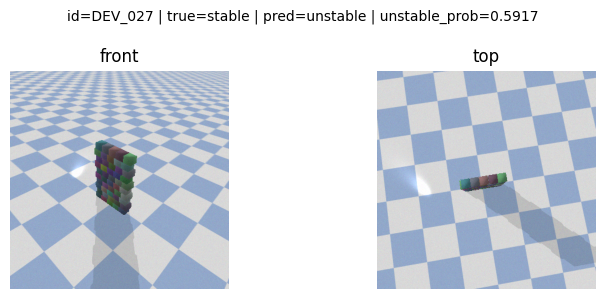

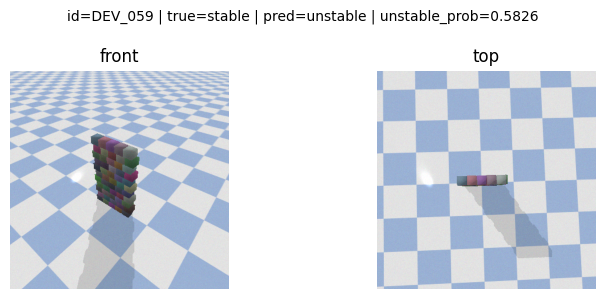

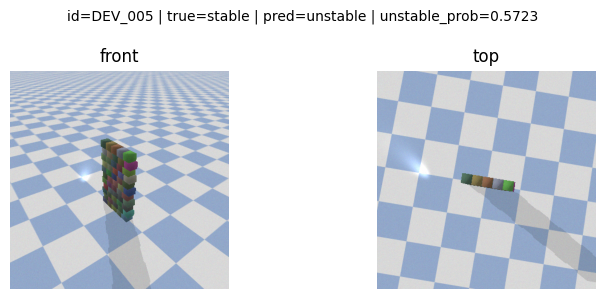

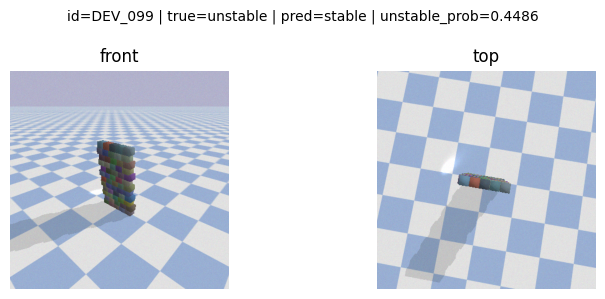

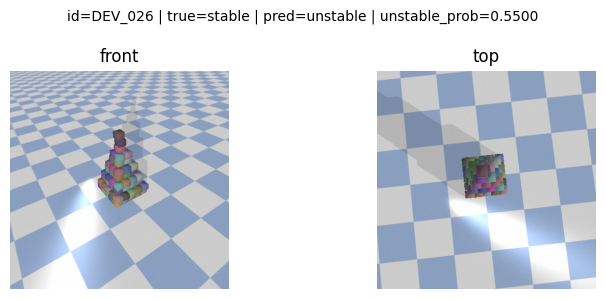

In [29]:
import matplotlib.pyplot as plt

TOP_N = 8  # 시각화할 오답 샘플 수
show_df = mistakes.head(TOP_N)

for _, row in show_df.iterrows():
    sample_id = row['id']
    front_path = DATA_DIR / 'dev' / sample_id / 'front.png'
    top_path = DATA_DIR / 'dev' / sample_id / 'top.png'

    fig, axes = plt.subplots(1, 2, figsize=(8, 3))
    axes[0].imshow(Image.open(front_path).convert('RGB'))
    axes[0].set_title('front')
    axes[0].axis('off')

    axes[1].imshow(Image.open(top_path).convert('RGB'))
    axes[1].set_title('top')
    axes[1].axis('off')

    fig.suptitle(
        f"id={sample_id} | true={row['label']} | pred={row['pred_label']} | unstable_prob={row['unstable_prob']:.4f}",
        fontsize=10
    )
    plt.tight_layout()
    plt.show()

## 8. 추론 및 제출 파일 생성

In [30]:
# 1) dev에서 TTA 조합 성능 비교
candidate_ttas = CFG['TTA_CANDIDATES']
tta_result_df = evaluate_tta_on_dev(student_model, val_loader, device, candidate_ttas)
display(tta_result_df)

best_tta_names = tta_result_df.iloc[0]['tta_names']
print(f"Best TTA on dev: {best_tta_names}")

# 2) best TTA로 test 추론
all_probs = predict_probs_with_tta(
    student_model, test_loader, device,
    tta_names=best_tta_names,
    has_labels=False,
    desc='Inference with TTA'
)

# 결과 저장
submission = pd.DataFrame({
    'id': test_df['id'],
    'unstable_prob': all_probs,
    'stable_prob': 1.0 - all_probs
})

submission.to_csv(submission_path, encoding='UTF-8-sig', index=False)
print(f'{submission_path} 저장 완료.')

Dev TTA ['none', 'hflip', 'crop95']: 100%|##########| 4/4 [00:22<00:00,  5.67s/it]


,tta_names,n_tta,val_logloss,val_acc
0,"[none, hflip, crop95]",3,0.283978,0.95
1,"[none, hflip]",2,0.288404,0.93
2,[none],1,0.292315,0.93


Best TTA on dev: ['none', 'hflip', 'crop95']


Inference with TTA: 100%|##########| 32/32 [01:49<00:00,  3.44s/it]


/home/vsc/LLM_TUNE/structure-stability/outputs/submissions/knowledge_distillation_v1.0.3.csv 저장 완료.
